# 05 — Three-Version Comparison Analysis

Compares three versions of the election results to assess OCR accuracy and imputation quality.

| Version | Description |
|---|---|
| **V1** | OCR output + imputation (current clean data) |
| **V2** | V1 proportionally scaled up to reference total |
| **V3** | Ground truth from `reference_constituency.json` / external CSVs |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from pathlib import Path

plt.rcParams['font.family'] = 'Tahoma'

ROOT         = Path('..').resolve()
CLEAN_PATH   = ROOT / 'data' / 'clean_data'
EXTERNAL     = ROOT / 'data' / 'external'

# ── Load V1 ──────────────────────────────────────────────────────────────────
v1_votes      = pd.read_csv(CLEAN_PATH / '5_18_votes.csv',      encoding='utf-8-sig')
v1_party      = pd.read_csv(CLEAN_PATH / '5_18_party_vote.csv', encoding='utf-8-sig')

# ── Load V3 reference ────────────────────────────────────────────────────────
candidates_ref = pd.read_csv(EXTERNAL / 'candidates.csv', encoding='utf-8-sig')
parties_ref    = pd.read_csv(EXTERNAL / 'parties.csv',    encoding='utf-8-sig')

print('V1 constituency vote rows:', len(v1_votes))
print('V1 party-list vote rows:  ', len(v1_party))
print('V3 candidates:', len(candidates_ref))
print('V3 parties:   ', len(parties_ref))

V1 constituency vote rows: 2002
V1 party-list vote rows:   15996
V3 candidates: 7
V3 parties:    57


In [2]:
# ── V1: aggregate ─────────────────────────────────────────────────────────────
v1_cand = (
    v1_votes.groupby('entity_name')['votes'].sum()
    .reset_index()
    .rename(columns={'votes': 'V1'})
)

v1_party_agg = (
    v1_party.groupby('entity_name')['votes'].sum()
    .reset_index()
    .rename(columns={'votes': 'V1'})
)

# ── V3: from external CSVs ───────────────────────────────────────────────────
v3_cand = candidates_ref[['candidate_name', 'votes_reference']].rename(
    columns={'candidate_name': 'entity_name', 'votes_reference': 'V3'}
)

v3_party = parties_ref[['party_name', 'votes_reference_constituency']].rename(
    columns={'party_name': 'entity_name', 'votes_reference_constituency': 'V3'}
)

# ── V2: proportional scale ───────────────────────────────────────────────────
ref_total_cand  = v3_cand['V3'].sum()
ref_total_party = v3_party['V3'].sum()

v1_total_cand  = v1_cand['V1'].sum()
v1_total_party = v1_party_agg['V1'].sum()

scale_cand  = ref_total_cand  / v1_total_cand
scale_party = ref_total_party / v1_total_party

print(f'Constituency  — V1 total: {v1_total_cand:,.0f} | V3 ref: {ref_total_cand:,.0f} | scale: {scale_cand:.4f}')
print(f'Party-list    — V1 total: {v1_total_party:,.0f} | V3 ref: {ref_total_party:,.0f} | scale: {scale_party:.4f}')

v1_cand['V2']       = (v1_cand['V1']       * scale_cand ).round().astype('Int64')
v1_party_agg['V2']  = (v1_party_agg['V1']  * scale_party).round().astype('Int64')

Constituency  — V1 total: 64,440 | V3 ref: 79,326 | scale: 1.2310
Party-list    — V1 total: 68,091 | V3 ref: 79,374 | scale: 1.1657


In [3]:
# ── Candidate comparison table ───────────────────────────────────────────────
cand_compare = (
    v1_cand
    .merge(v3_cand, on='entity_name', how='outer')
    .sort_values('V3', ascending=False)
    .reset_index(drop=True)
)
cand_compare['V1_accuracy%'] = (cand_compare['V1'] / cand_compare['V3'] * 100).round(1)
cand_compare['V2_accuracy%'] = (cand_compare['V2'] / cand_compare['V3'] * 100).round(1)

print('=== Constituency Candidate Comparison ===')
print(cand_compare.to_string(index=False))

=== Constituency Candidate Comparison ===
                entity_name      V1    V2    V3  V1_accuracy%  V2_accuracy%
      นายเชิงชาย ชาลีรินทร์ 45546.0 56067 54996          82.8         101.9
      นางสาววาสนา อยู่ภักดี 10183.0 12535 14658          69.5          85.5
        นายทัศนัย สุขประสาร  3221.0  3965  3538          91.0         112.1
         นายโสโชค สู้โนนตาด  1569.0  1931  1879          83.5         102.8
          นายถวัลย์ หงษ์ไทย  1108.0  1364  1687          65.7          80.9
                ณรงค์ แขนอก  1628.0  2004  1314         123.9         152.5
นายประเสริฐศักดิ์ ขำหินตั้ง  1185.0  1459  1254          94.5         116.3


In [4]:
# ── Party-list comparison table ──────────────────────────────────────────────
party_compare = (
    v1_party_agg
    .merge(v3_party, on='entity_name', how='outer')
    .sort_values('V3', ascending=False)
    .reset_index(drop=True)
)
party_compare['V1_accuracy%'] = (party_compare['V1'] / party_compare['V3'] * 100).round(1)
party_compare['V2_accuracy%'] = (party_compare['V2'] / party_compare['V3'] * 100).round(1)

print('=== Top 15 Parties Comparison ===')
print(party_compare.head(15).to_string(index=False))

=== Top 15 Parties Comparison ===
    entity_name      V1    V2    V3  V1_accuracy%  V2_accuracy%
       เพื่อไทย 19719.0 22987 25099          78.6          91.6
        ประชาชน 13466.0 15697 20039          67.2          78.3
      ภูมิใจไทย  6307.0  7352  7952          79.3          92.5
       เศรษฐกิจ  3916.0  4565  4338          90.3         105.2
           ใหม่  3212.0  3744  3813          84.2          98.2
   ประชาธิปัตย์  2718.0  3168  3597          75.6          88.1
   เพื่อชาติไทย  2890.0  3369  3046          94.9         110.6
รวมไทยสร้างชาติ  1343.0  1566  1659          81.0          94.4
       รวมใจไทย   778.0   907   883          88.1         102.7
 รวมพลังประชาชน   661.0   771   752          87.9         102.5
ประชาธิปไตยใหม่   647.0   754   646         100.2         116.7
     เสรีรวมไทย   655.0   764   613         106.9         124.6
   ไทยทรัพย์ทวี   805.0   938   592         136.0         158.4
    ไทยสร้างไทย   490.0   571   456         107.5         125.2
   ทาง

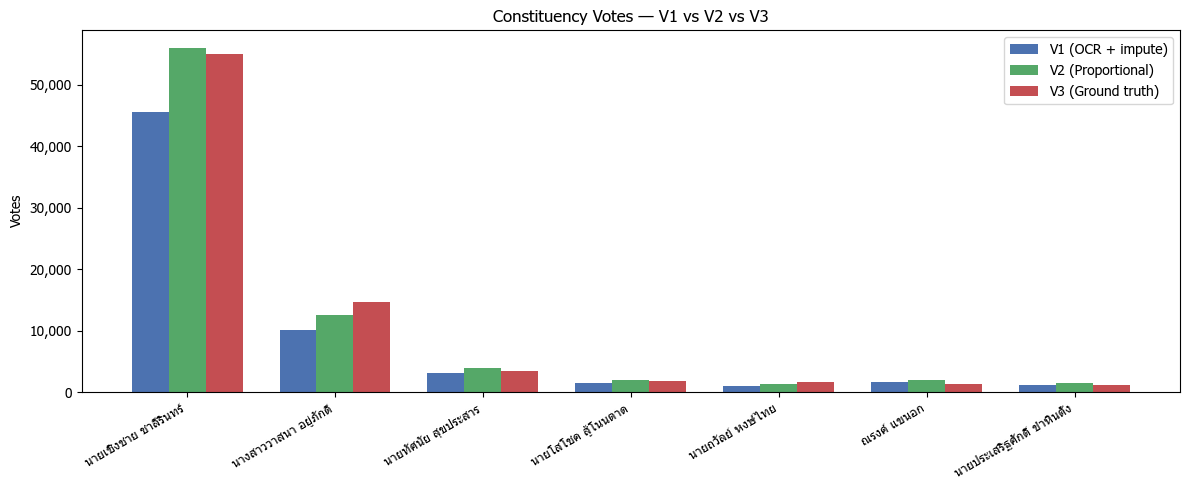

In [5]:
# ── Candidate bar chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(cand_compare))
w = 0.25

ax.bar(x - w,   cand_compare['V1'], w, label='V1 (OCR + impute)', color='#4C72B0')
ax.bar(x,       cand_compare['V2'], w, label='V2 (Proportional)', color='#55A868')
ax.bar(x + w,   cand_compare['V3'], w, label='V3 (Ground truth)', color='#C44E52')

ax.set_xticks(x)
ax.set_xticklabels(cand_compare['entity_name'], rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{val:,.0f}'))
ax.set_title('Constituency Votes — V1 vs V2 vs V3')
ax.set_ylabel('Votes')
ax.legend()
plt.tight_layout()
plt.show()

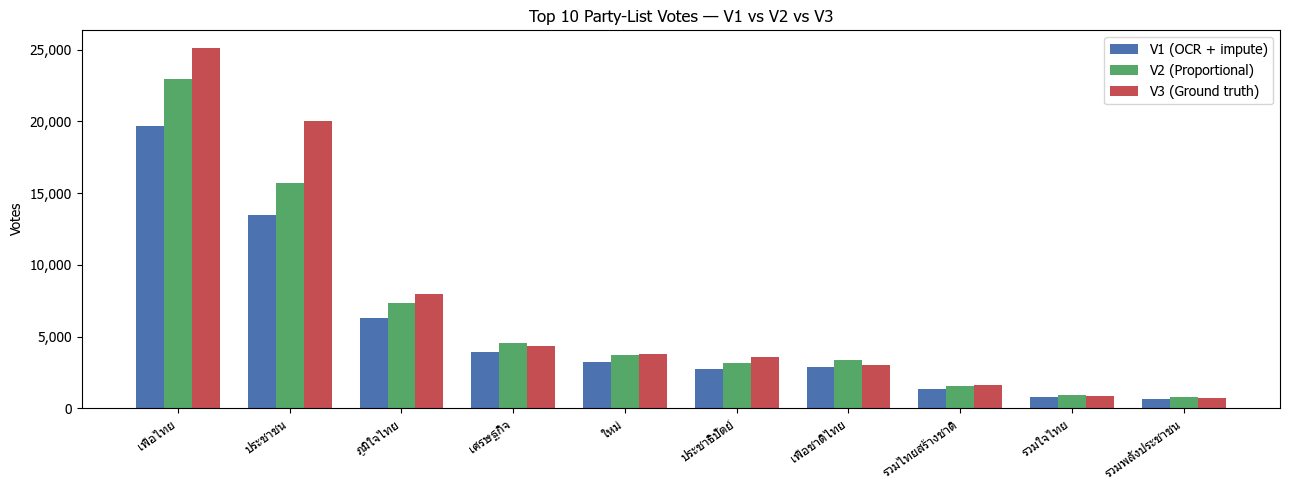

In [6]:
# ── Top 10 parties bar chart ──────────────────────────────────────────────────
top10 = party_compare.dropna(subset=['V3']).head(10)

fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(top10))
w = 0.25

ax.bar(x - w,   top10['V1'], w, label='V1 (OCR + impute)', color='#4C72B0')
ax.bar(x,       top10['V2'], w, label='V2 (Proportional)', color='#55A868')
ax.bar(x + w,   top10['V3'], w, label='V3 (Ground truth)', color='#C44E52')

ax.set_xticks(x)
ax.set_xticklabels(top10['entity_name'], rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{val:,.0f}'))
ax.set_title('Top 10 Party-List Votes — V1 vs V2 vs V3')
ax.set_ylabel('Votes')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# ── Winner & margin summary ───────────────────────────────────────────────────
print('=' * 55)
print('WINNER & MARGIN SUMMARY')
print('=' * 55)

for ver in ['V1', 'V2', 'V3']:
    top2 = cand_compare.nlargest(2, ver).reset_index(drop=True)
    winner = top2.loc[0, 'entity_name']
    margin = top2.loc[0, ver] - top2.loc[1, ver]
    total  = cand_compare[ver].sum()
    pct    = margin / total * 100
    print(f'\n{ver}: Winner = {winner}')
    print(f'     Margin = {margin:,.0f} votes ({pct:.1f}% of total)')

print()
print('=' * 55)
print('OVERALL OCR COVERAGE')
print('=' * 55)
print(f'Constituency : {v1_total_cand/ref_total_cand*100:.1f}%  ({v1_total_cand:,.0f} / {ref_total_cand:,.0f})')
print(f'Party-list   : {v1_total_party/ref_total_party*100:.1f}%  ({v1_total_party:,.0f} / {ref_total_party:,.0f})')

WINNER & MARGIN SUMMARY

V1: Winner = นายเชิงชาย ชาลีรินทร์
     Margin = 35,363 votes (54.9% of total)

V2: Winner = นายเชิงชาย ชาลีรินทร์
     Margin = 43,532 votes (54.9% of total)

V3: Winner = นายเชิงชาย ชาลีรินทร์
     Margin = 40,338 votes (50.9% of total)

OVERALL OCR COVERAGE
Constituency : 81.2%  (64,440 / 79,326)
Party-list   : 85.8%  (68,091 / 79,374)
